<a href="https://colab.research.google.com/github/PherKyaRakhun/Hmm_testing/blob/Exploration-And-Analysis/vehicle_maintenance_prediction_grouped_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Vehicle Maintenance Prediction



---
## Part 1 — Data Loading & Exploration


In [ ]:
!pip install -q imbalanced-learn pandas scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [ ]:
df = pd.read_csv('/content/vehicle_maintenance_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (50000, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


### Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

### Describe

In [ ]:
df.describe(include='all')

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
count,50000,50000.000000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000.00000,50000.000000,50000,50000,50000,50000.000000
unique,6,NaN,3,NaN,NaN,3,2,NaN,NaN,336,701,3,NaN,NaN,NaN,NaN,3,3,3,NaN
top,Bus,NaN,Average,NaN,NaN,Diesel,Manual,NaN,NaN,2023-11-25,2024-09-16,Second,NaN,NaN,NaN,NaN,New,Worn Out,New,NaN
freq,8414,NaN,16724,NaN,NaN,16738,25009,NaN,NaN,182,101,16875,NaN,NaN,NaN,NaN,16825,16685,16725,NaN
mean,NaN,54931.232680,NaN,2.497420,5.492260,NaN,NaN,1556.292000,75551.187060,NaN,NaN,NaN,17465.340700,5.515560,1.50156,14.990323,NaN,NaN,NaN,0.809960
std,NaN,14401.912925,NaN,1.708781,2.875682,NaN,NaN,627.677218,43088.105658,NaN,NaN,NaN,7223.393401,2.874899,1.11951,2.885583,NaN,NaN,NaN,0.392336
min,NaN,30001.000000,NaN,0.000000,1.000000,NaN,NaN,800.000000,1001.000000,NaN,NaN,NaN,5000.000000,1.000000,0.00000,10.000098,NaN,NaN,NaN,0.000000
25%,NaN,42471.500000,NaN,1.000000,3.000000,NaN,NaN,1000.000000,38009.000000,NaN,NaN,NaN,11189.750000,3.000000,0.00000,12.489037,NaN,NaN,NaN,1.000000
50%,NaN,54810.000000,NaN,2.000000,5.000000,NaN,NaN,1500.000000,75598.500000,NaN,NaN,NaN,17477.500000,6.000000,2.00000,14.986352,NaN,NaN,NaN,1.000000
75%,NaN,67391.500000,NaN,4.000000,8.000000,NaN,NaN,2000.000000,112999.500000,NaN,NaN,NaN,23692.000000,8.000000,3.00000,17.474676,NaN,NaN,NaN,1.000000


### Duplicate Check

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (50000, 20)


### Missing Value Check

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Vehicle_Model           0
Mileage                 0
Maintenance_History     0
Reported_Issues         0
Vehicle_Age             0
Fuel_Type               0
Transmission_Type       0
Engine_Size             0
Odometer_Reading        0
Last_Service_Date       0
Warranty_Expiry_Date    0
Owner_Type              0
Insurance_Premium       0
Service_History         0
Accident_History        0
Fuel_Efficiency         0
Tire_Condition          0
Brake_Condition         0
Battery_Status          0
Need_Maintenance        0
dtype: int64


---
## Part 2 — Feature/Target Setup & Cleaning


In [ ]:
feature_columns = [
    'Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues',
    'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size',
    'Odometer_Reading', 'Last_Service_Date', 'Warranty_Expiry_Date',
    'Owner_Type', 'Insurance_Premium', 'Service_History', 'Accident_History',
    'Fuel_Efficiency', 'Tire_Condition', 'Brake_Condition', 'Battery_Status'
]
target_column = 'Need_Maintenance'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 19)
Target shape: (50000,)


### Handle Missing Values

In [ ]:
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

X[numerical_cols] = X[numerical_cols].fillna(X[numerical_cols].median())
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values handled.")

Missing values handled.


### Encode Categorical Columns

In [ ]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Categorical columns encoded.")
X.head()

Categorical columns encoded.


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status
0,4,58765,1,0,4,1,0,2000,28524,238,422,1,20782,6,3,13.622204,1,1,2
1,5,60353,0,1,7,1,0,2500,133630,175,402,1,23489,7,0,13.625307,1,1,2
2,0,68072,2,0,2,1,0,1500,34022,89,364,0,17979,7,0,14.306302,1,0,2
3,0,60849,0,4,5,2,0,2500,81636,147,556,1,6220,7,3,18.709467,1,2,1
4,0,45742,2,5,1,2,1,2000,97162,56,504,2,16446,6,2,16.977482,0,0,2


---
## Part 3 — Balancing & Train/Test Split


### Class Distribution Before SMOTE

Text(0, 0.5, 'Number of Samples')

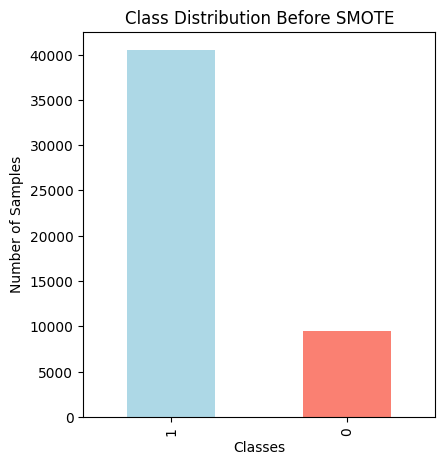

In [ ]:
# print(y.value_counts())
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')

### Apply SMOTE

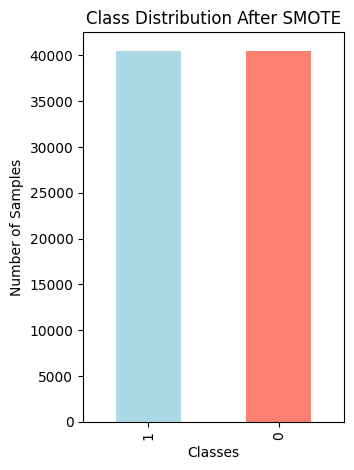

In [ ]:
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

# print("Before SMOTE:", X.shape)
# print("After SMOTE:", X_bal.shape)
# print(y_bal.value_counts())
plt.subplot(1, 2, 2)
y_bal.value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Distribution After SMOTE')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')

# Show the plot
plt.tight_layout()
plt.show()

### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.30, random_state=42, stratify=y_bal
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 56697
Testing samples: 24299


---
## Part 4 — Model Training


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN (k = 5)': KNeighborsClassifier(n_neighbors=5),
    'Ensemble Learning': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(random_state=42)),
            ('rf', RandomForestClassifier(random_state=42)),
            ('gb', GradientBoostingClassifier(random_state=42))
        ],
        voting='hard'
    )
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("All models trained.")

All models trained.


---
## Part 5 — Final Scores


In [ ]:
results = []
for name, preds in predictions.items():
    final_score = f1_score(y_test, preds, zero_division=0) * 100
    results.append({
        'Algorithm': name,
        'Final Score (%)': final_score
    })

results_df = pd.DataFrame(results).sort_values('Final Score (%)', ascending=False).reset_index(drop=True)
results_df

,Algorithm,Final Score (%)
0,Random Forest,99.987655
1,Gradient Boosting,99.987655
2,Ensemble Learning,99.987655
3,Decision Tree,99.971183
4,Naive Bayes,83.012341
5,KNN (k = 5),66.812376


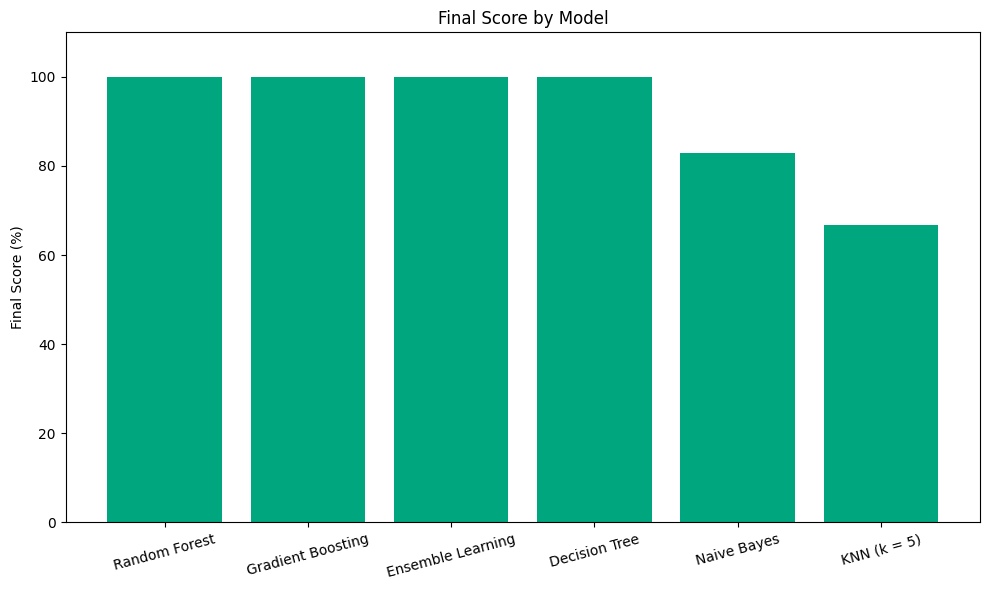

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Algorithm'], results_df['Final Score (%)'], color='#00A67E')

plt.xticks(rotation=15)
plt.ylabel('Final Score (%)')
plt.ylim(0, 110)
plt.title('Final Score by Model')
plt.tight_layout()
plt.show()